# QUWI Image Preprocessing

This notebook develops and validates a reproducible preprocessing pipeline for QUWI handwriting images.

## Goals

- Preserve the original aspect ratio
- Avoid geometric distortion
- Pad images to a fixed canvas size
- Compare RGB and grayscale representations
- Handle portrait and nonstandard cropped samples consistently
- Convert processed images into model-ready tensors
- Save the selected preprocessing configuration

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torchvision.transforms import functional as TF

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

QUWI_ROOT = Path.home() / "Documents" / "Handwriting" / "QUWI"
IMAGE_DIR = QUWI_ROOT / "extracted" / "images"
MANIFEST_PATH = PROJECT_ROOT / "manifests" / "quwi_image_manifest.csv"
SPLIT_PATH = PROJECT_ROOT / "splits" / "quwi_writer_disjoint_split_seed42.csv"

manifest_df = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

data_df = manifest_df.merge(
    split_df,
    on="filename",
    validate="one_to_one",
    suffixes=("_manifest", "_split"),
)

print("Project root:", PROJECT_ROOT)
print("Image directory exists:", IMAGE_DIR.exists())
print("Manifest rows:", len(manifest_df))
print("Split rows:", len(split_df))
print("Combined rows:", len(data_df))

Project root: /home/arijit/Documents/handwriting-cross-script-research
Image directory exists: True
Manifest rows: 1900
Split rows: 1900
Combined rows: 1900


In [3]:
def resize_with_padding(
    image,
    target_size=(384, 384),
    output_mode="RGB",
    fill_value=255,
):
    original_size = image.size
    converted_image = image.convert(output_mode)

    resized_image = ImageOps.contain(
        converted_image,
        target_size,
        method=Image.Resampling.LANCZOS,
    )

    if output_mode == "RGB":
        fill = (fill_value, fill_value, fill_value)
    else:
        fill = fill_value

    canvas = Image.new(output_mode, target_size, fill)

    left = (target_size[0] - resized_image.width) // 2
    top = (target_size[1] - resized_image.height) // 2

    canvas.paste(resized_image, (left, top))

    padding = {
        "left": left,
        "top": top,
        "right": target_size[0] - resized_image.width - left,
        "bottom": target_size[1] - resized_image.height - top,
    }

    return canvas, {
        "original_size": original_size,
        "resized_size": resized_image.size,
        "output_size": canvas.size,
        "padding": padding,
    }


sample_path = IMAGE_DIR / "0001_1.jpg"

with Image.open(sample_path) as image:
    processed_sample, sample_info = resize_with_padding(image)

print("Filename:", sample_path.name)
print("Original size:", sample_info["original_size"])
print("Resized size:", sample_info["resized_size"])
print("Output size:", sample_info["output_size"])
print("Padding:", sample_info["padding"])
print("Output mode:", processed_sample.mode)

assert processed_sample.size == (384, 384)
assert processed_sample.mode == "RGB"

Filename: 0001_1.jpg
Original size: (2465, 3383)
Resized size: (280, 384)
Output size: (384, 384)
Padding: {'left': 52, 'top': 0, 'right': 52, 'bottom': 0}
Output mode: RGB


In [4]:
inspection_filenames = [
    "0001_1.jpg",
    "0428_2.jpg",
    "0221_4.jpg",
]

preprocessing_examples = []

for filename in inspection_filenames:
    image_path = IMAGE_DIR / filename

    with Image.open(image_path) as image:
        original_image = image.convert("RGB")
        processed_image, processing_info = resize_with_padding(
            image,
            target_size=(384, 384),
            output_mode="RGB",
        )

    preprocessing_examples.append(
        {
            "filename": filename,
            "original": original_image,
            "processed": processed_image,
            "info": processing_info,
        }
    )

    print(
        filename,
        processing_info["original_size"],
        "->",
        processing_info["resized_size"],
        "padding:",
        processing_info["padding"],
    )

0001_1.jpg (2465, 3383) -> (280, 384) padding: {'left': 52, 'top': 0, 'right': 52, 'bottom': 0}
0428_2.jpg (2313, 2201) -> (384, 365) padding: {'left': 0, 'top': 9, 'right': 0, 'bottom': 10}
0221_4.jpg (2472, 1112) -> (384, 173) padding: {'left': 0, 'top': 105, 'right': 0, 'bottom': 106}


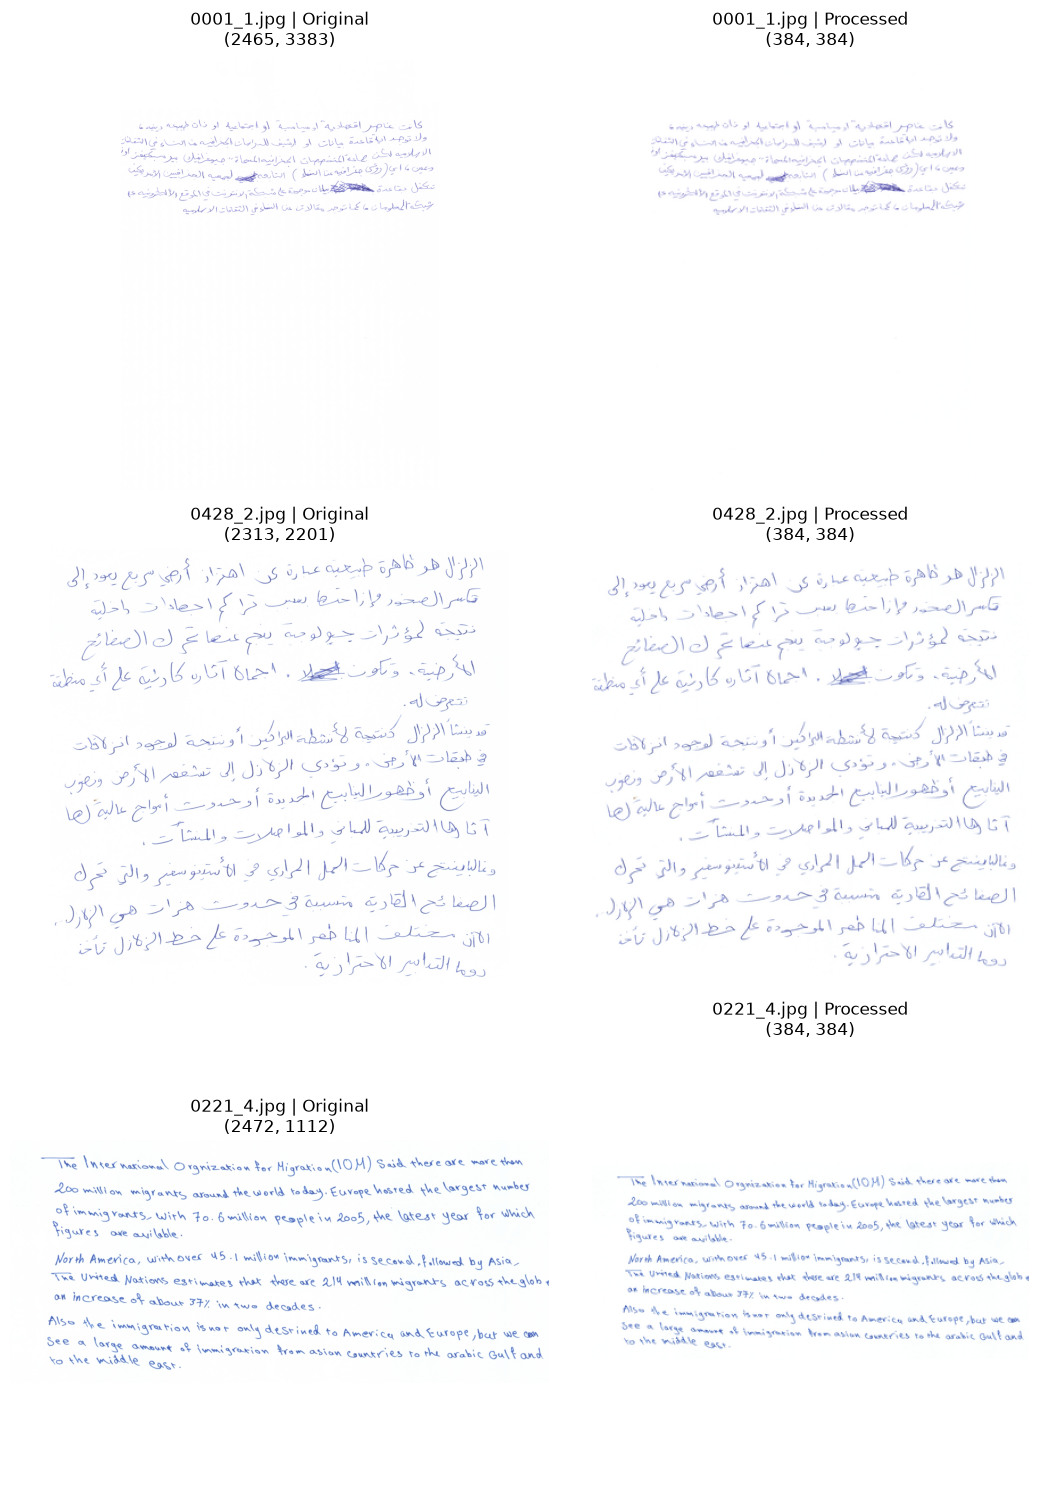

In [5]:
figure, axes = plt.subplots(3, 2, figsize=(11, 15))

for row_index, example in enumerate(preprocessing_examples):
    axes[row_index, 0].imshow(example["original"])
    axes[row_index, 0].set_title(
        f"{example['filename']} | Original\n"
        f"{example['info']['original_size']}"
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(example["processed"])
    axes[row_index, 1].set_title(
        f"{example['filename']} | Processed\n"
        f"{example['info']['output_size']}"
    )
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()

In [6]:
variant_filenames = [
    "0001_1.jpg",
    "0002_4.jpg",
    "0212_4.jpg",
]

image_variants = []

for filename in variant_filenames:
    with Image.open(IMAGE_DIR / filename) as image:
        rgb_image, _ = resize_with_padding(
            image,
            target_size=(384, 384),
            output_mode="RGB",
        )

        grayscale_image, _ = resize_with_padding(
            image,
            target_size=(384, 384),
            output_mode="L",
        )

        autocontrast_image = ImageOps.autocontrast(
            grayscale_image,
            cutoff=0.5,
        )

    image_variants.append(
        {
            "filename": filename,
            "rgb": rgb_image,
            "grayscale": grayscale_image,
            "autocontrast": autocontrast_image,
        }
    )

print("Prepared variants:", len(image_variants))

Prepared variants: 3


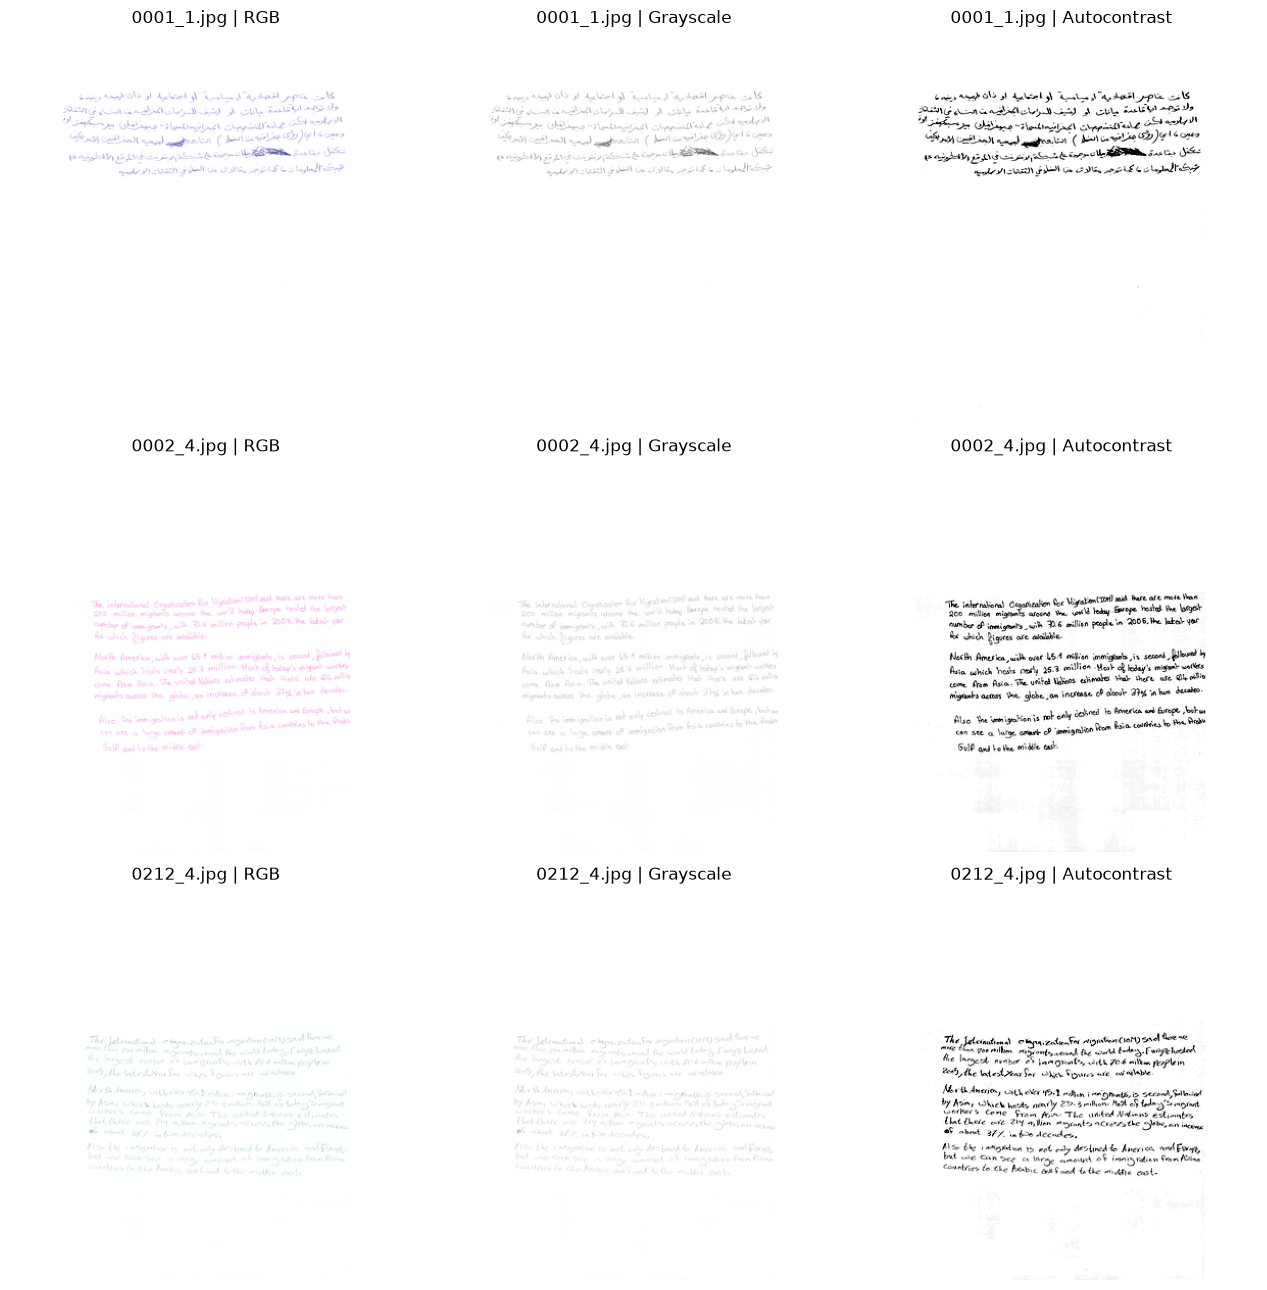

In [7]:
figure, axes = plt.subplots(3, 3, figsize=(13, 13))

for row_index, example in enumerate(image_variants):
    axes[row_index, 0].imshow(example["rgb"])
    axes[row_index, 0].set_title(f"{example['filename']} | RGB")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(
        example["grayscale"],
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axes[row_index, 1].set_title(f"{example['filename']} | Grayscale")
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(
        example["autocontrast"],
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axes[row_index, 2].set_title(f"{example['filename']} | Autocontrast")
    axes[row_index, 2].axis("off")

plt.tight_layout()
plt.show()